# Assignment 1: Principal Component Analysis (PCA)

## DTSC-680: Applied Machine Learning

## Name:


### Overview

In this assignment, you will import a high dimensional dataset and reduce the dimensions of the data in order to visualize the clusters that exist within the data. You will use both PCA and t-SNE to perform dimensionality reduction.

In [1]:
# common imports
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

### Data Prep

The penguins dataset is included in the `penguins.csv` file. Read the penguins data into a pandas DataFrame called `penguins`. To ensure compatibility across different operating systems, make sure to use the encoding='utf-8' parameter.

In [2]:
penguins = pd.read_csv('penguins.csv', encoding='utf-8')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Before we can perform any dimensionality reduction or Machine Learning task, the data needs to be cleaned. Perform the following data cleaning and preprocessing tasks:
- Drop any rows containing NULL values.
- Use scikit-learn's [`Label Encoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) to encode the categorical columns to numerical values.
- Split the data into a Series called `species` containing the species column and the `penguins` dataframe containing all of the other columns.

In [3]:
penguins.dropna(inplace=True)

In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in ['island', 'sex']:
    le = LabelEncoder()
    penguins[col] = le.fit_transform(penguins[col])
    label_encoders[col] = le

In [5]:
species = penguins['species']
penguins = penguins.drop(columns=['species'])

### Reduce Dimensions for Visualization Using PCA

Use PCA to reduce the dimensions of the dataset so that the clusters can be visualized. Call the PCA'ed dataframe `pca_penguins`, setting the random state to 0. Then, run the cell below to plot the PCA'ed data. Lastly, store the array containing the explained variance ratio as `exp_variance`. 

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

le = LabelEncoder()
species_encoded = le.fit_transform(species)

pca = PCA(n_components=2, random_state=0)
pca_penguins = pca.fit_transform(penguins)
exp_variance = pca.explained_variance_ratio_

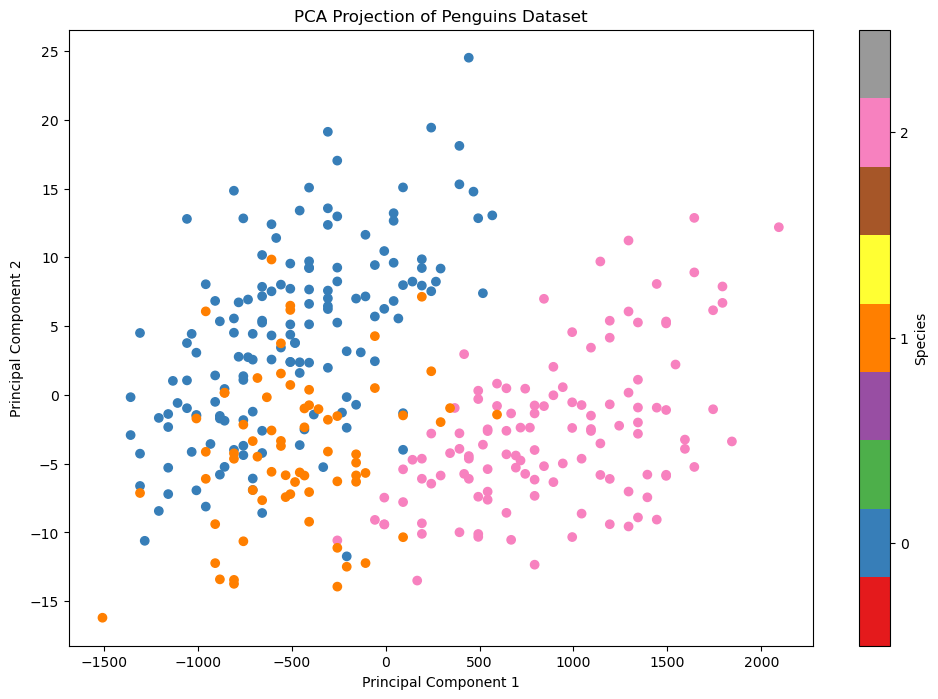

In [7]:
# CODE PROVIDED
plt.figure(figsize=(12, 8))
plt.scatter(pca_penguins[:, 0], pca_penguins[:, 1], c=species_encoded, cmap=plt.colormaps['Set1'])
plt.title('PCA Projection of Penguins Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.clim(-0.5, 2.5)
plt.colorbar(ticks=[0, 1, 2], label='Species')
plt.show()

In [ ]:
# STUDENTS CODE

### Reduce Dimensions for Visualization Using t-SNE

Now, use t-SNE to perform the same dimensionality reduction. Call the t-SNE'ed dataframe `tsne_penguins` setting the random state to 0, and then run the cell below to plot the t-SNE'ed data.

In [10]:
from sklearn.preprocessing import LabelEncoder

encoded_species = LabelEncoder().fit_transform(species)

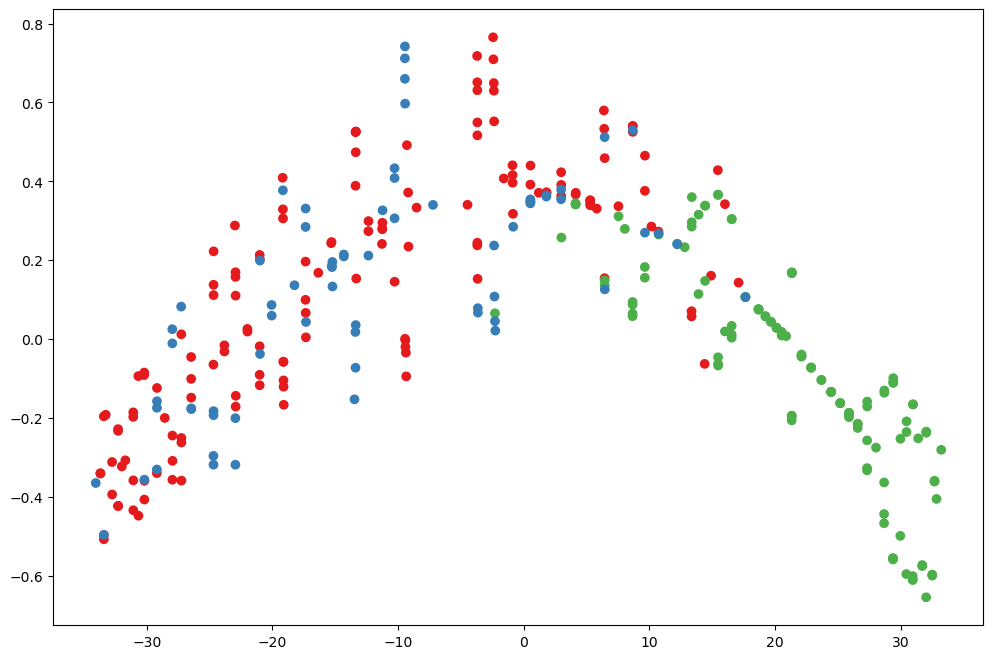

In [12]:
# CODE PROVIDED
plt.figure(figsize=(12, 8))
plt.scatter(tsne_penguins[:, 0], tsne_penguins[:, 1], c=encoded_species, cmap=plt.colormaps['Set1'])
plt.clim(-0.5, 9.5)

### Reduce Dimensions for Visualization Using PCA and t-SNE

Finally, use t-SNE to perform dimensionality reduction on the PCA'ed penguins data. Call this dataframe `pca_tsne_penguins` and run the following cell to plot the new data.

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
pca_tsne_penguins = tsne.fit_transform(pca_penguins)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
pca_penguins = pca.fit_transform(penguins)

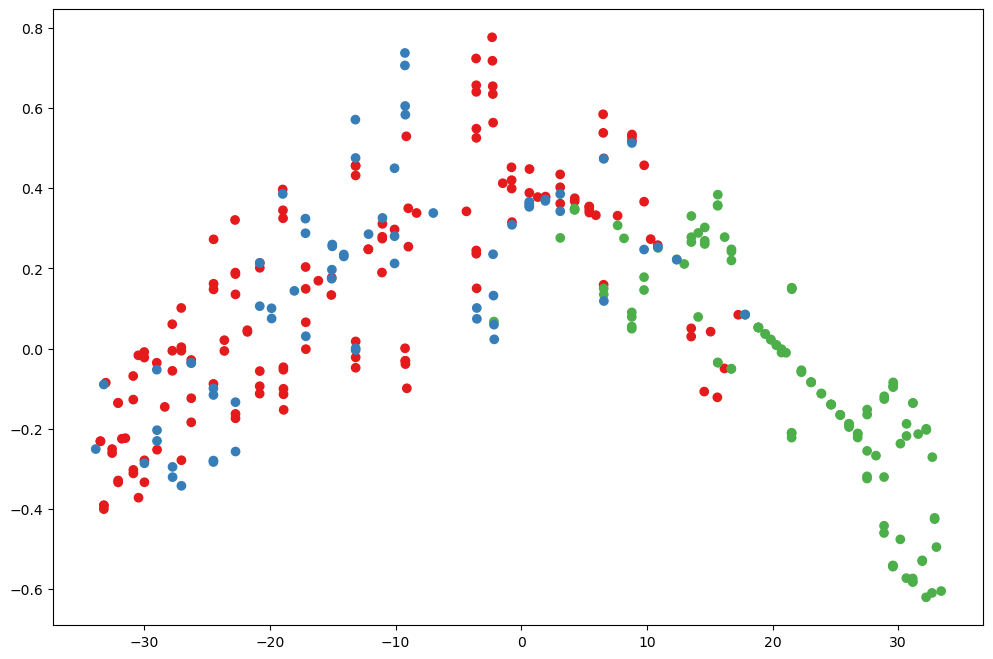

In [17]:
from sklearn.preprocessing import LabelEncoder
encoded_species = LabelEncoder().fit_transform(species)

%matplotlib inline
plt.figure(figsize=(12, 8))
plt.scatter(pca_tsne_penguins[:, 0], pca_tsne_penguins[:, 1], c=encoded_species, cmap=plt.colormaps['Set1'])
plt.clim(-0.5, 9.5)

Take a minute to look at the three plots. Which plot seperates the clusters most clearly?

### Export cleaned penguins dataset for codegrade evaluation
Using the "pickle" library:

Export the cleaned penguins dataset as "cleaned_peguins.pkl".

In [18]:
import pickle

with open('cleaned_penguins.pkl', 'wb') as file:
    pickle.dump(penguins, file)  # --> MAKE SURE TO EXPORT THE RIGHT DATASET

In [19]:
penguins.info()
penguins.head()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   island             333 non-null    int32  
 1   bill_length_mm     333 non-null    float64
 2   bill_depth_mm      333 non-null    float64
 3   flipper_length_mm  333 non-null    float64
 4   body_mass_g        333 non-null    float64
 5   sex                333 non-null    int32  
 6   year               333 non-null    int64  
dtypes: float64(4), int32(2), int64(1)
memory usage: 18.2 KB


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,2,39.1,18.7,181.0,3750.0,1,2007
1,2,39.5,17.4,186.0,3800.0,0,2007
2,2,40.3,18.0,195.0,3250.0,0,2007
4,2,36.7,19.3,193.0,3450.0,0,2007
5,2,39.3,20.6,190.0,3650.0,1,2007


### Export Models for codegrade evaluation
Using the "pickle" library:

Export the models as "pca_penguins.pkl", "pca_tsne_penguins.pkl" and "tsne_penguins".

In [21]:
# CODE PROVIDED
#Save PCA MODEL to file
with open('pca_penguins.pkl', 'wb') as file:
    pickle.dump(pca_penguins , file)   ## --> MAKE SURE TO EXPORT THE RIGHT MODEL

#Save TSNE_PCA MODEL to file
with open('pca_tsne_penguins.pkl', 'wb') as file:
    pickle.dump(pca_tsne_penguins , file)   ## --> MAKE SURE TO EXPORT THE RIGHT MODEL

#Save TSE MODEL to file
with open('tsne_penguins.pkl', 'wb') as file:
    pickle.dump(tsne_penguins , file)   ## --> MAKE SURE TO EXPORT THE RIGHT MODEL